# Secure Multimodal High Fidelity Reconstruction with DWT and RSA-AES

In [1]:
import cv2
import numpy as np
from Crypto.Cipher import AES, PKCS1_OAEP
from Crypto.PublicKey import RSA
from Crypto.Random import get_random_bytes

In [2]:
def load_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Error: Image not found at {image_path}")

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    print(f"Image loaded: Shape {img.shape}")
    return img

## Apply 2D-DWT (Discrete Wavelet Transform)

In [3]:
def apply_dwt(image):
    coeffs2 = pywt.dwt2(image.astype(np.float32), 'haar')  
    LL, (LH, HL, HH) = coeffs2
    return LL, (LH, HL, HH)

## AES Encryption

In [4]:
def encrypt_aes(data, key):
    cipher = AES.new(key, AES.MODE_EAX)
    ciphertext, tag = cipher.encrypt_and_digest(data)
    return cipher.nonce, ciphertext, tag

## AES Decryption

In [5]:
def decrypt_aes(nonce, ciphertext, tag, key):
    cipher = AES.new(key, AES.MODE_EAX, nonce=nonce)
    data = cipher.decrypt_and_verify(ciphertext, tag)
    return data

## RSA Key Generation

In [6]:
def generate_rsa_keys():
    key = RSA.generate(2048)
    private_key = key.export_key()
    public_key = key.publickey().export_key()
    return private_key, public_key

## RSA Encrypt AES Key

In [7]:
def encrypt_rsa(data, public_key):
    recipient_key = RSA.import_key(public_key)
    cipher_rsa = PKCS1_OAEP.new(recipient_key)
    encrypted_data = cipher_rsa.encrypt(data)
    return encrypted_data

## RSA Decrypt AES Key

In [8]:
def decrypt_rsa(encrypted_data, private_key):
    key = RSA.import_key(private_key)
    cipher_rsa = PKCS1_OAEP.new(key)
    decrypted_data = cipher_rsa.decrypt(encrypted_data)
    return decrypted_data

## Inverse DWT (Reconstruction)

In [9]:
def apply_idwt(LL, subbands):
    reconstructed_image = pywt.idwt2((LL, subbands), 'haar')
    return reconstructed_image

In [13]:
def main():
    image_path ="C:\\Users\\Kovarthana\\Pictures\\Personal files\\bebd261301e011a4b94c162e42241e12.jpg"
    img = load_image(image_path)
    LL, subbands = apply_dwt(img)

    
    LL_norm = (LL - np.min(LL)) / (np.max(LL) - np.min(LL))  # Normalize 0-1
    LL_bytes = (LL_norm * 255).astype(np.uint8).tobytes()

   
    aes_key = get_random_bytes(16)
    nonce, ciphertext, tag = encrypt_aes(LL_bytes, aes_key)
    
   
    private_key, public_key = generate_rsa_keys()
    encrypted_aes_key = encrypt_rsa(aes_key, public_key)
    
   
    decrypted_aes_key = decrypt_rsa(encrypted_aes_key, private_key)
    
    
    decrypted_LL_bytes = decrypt_aes(nonce, ciphertext, tag, decrypted_aes_key)

   
    decrypted_LL_uint8 = np.frombuffer(decrypted_LL_bytes, dtype=np.uint8).reshape(LL.shape)
    decrypted_LL = decrypted_LL_uint8.astype(np.float32) / 255 * (np.max(LL) - np.min(LL)) + np.min(LL)
    
    
    reconstructed_img = apply_idwt(decrypted_LL, subbands)

  
    cv2.imwrite('reconstructed_image.jpg', np.clip(reconstructed_img, 0, 255).astype(np.uint8))
    print("Encryption, Transmission, and Decryption Completed Successfully!")

In [14]:
import pywt
if __name__ == '__main__':
    main()

Image loaded: Shape (720, 722)
Encryption, Transmission, and Decryption Completed Successfully!


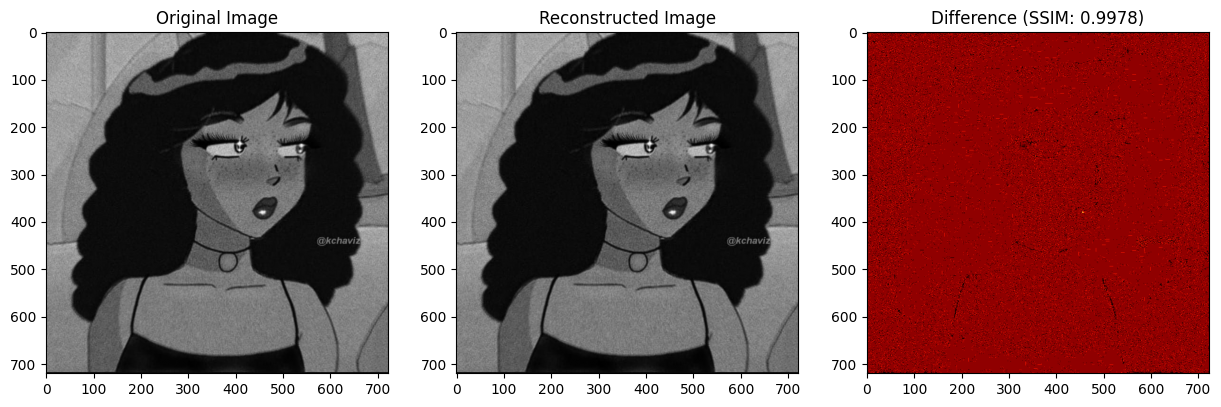

Structural Similarity Index (SSIM): 0.9978


In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

image_path ="C:\\Users\\Kovarthana\\Pictures\\Personal files\\bebd261301e011a4b94c162e42241e12.jpg"

original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
reconstructed = cv2.imread("reconstructed_image.jpg", cv2.IMREAD_GRAYSCALE)

if original is None:
    raise ValueError(f"Error: Original image not found at {image_path}")
if reconstructed is None:
    raise ValueError("Error: Decrypted image 'decrypted_image.jpg' not found. Check if decryption was successful.")

difference = cv2.absdiff(original, reconstructed)

ssim_index, diff_map = ssim(original, reconstructed, full=True)
diff_map = (diff_map * 255).astype(np.uint8)  # Normalize to 0-255 for visualization

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original, cmap='gray')
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(reconstructed, cmap='gray')
plt.title("Reconstructed Image")

plt.subplot(1, 3, 3)
plt.imshow(difference, cmap='hot')
plt.title(f"Difference (SSIM: {ssim_index:.4f})")

plt.show()

# Print SSIM Score
print(f"Structural Similarity Index (SSIM): {ssim_index:.4f}")


# Colored Image Reconstruction

In [29]:
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim


image_path = "C:\\Users\\Kovarthana\\Pictures\\Personal files\\bebd261301e011a4b94c162e42241e12.jpg" 
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 

## Split into R, G, B channels

In [18]:
r, g, b = cv2.split(image)

## Apply DWT on a single channel

In [ ]:
def apply_dwt(channel):
    LL, (LH, HL, HH) = pywt.dwt2(channel.astype(np.float32), 'haar')
    return LL, (LH, HL, HH)

## Apply DWT to each channel

In [21]:
LL_r, (LH_r, HL_r, HH_r) = apply_dwt(r)
LL_g, (LH_g, HL_g, HH_g) = apply_dwt(g)
LL_b, (LH_b, HL_b, HH_b) = apply_dwt(b)

## Reconstruction using Inverse DWT (IDWT)

In [22]:
def reconstruct_dwt(LL, LH, HL, HH):
    return pywt.idwt2((LL, (LH, HL, HH)), 'haar')

## Apply inverse DWT 

In [23]:
r_reconstructed = reconstruct_dwt(LL_r, LH_r, HL_r, HH_r)
g_reconstructed = reconstruct_dwt(LL_g, LH_g, HL_g, HH_g)
b_reconstructed = reconstruct_dwt(LL_b, LH_b, HL_b, HH_b)

## Merge channels back into a colored image

In [24]:
reconstructed_image = cv2.merge((r_reconstructed, g_reconstructed, b_reconstructed))
reconstructed_image = np.clip(reconstructed_image, 0, 255).astype(np.uint8)  # Ensure valid pixel range

## Compute PSNR and SSIM

In [27]:
psnr_value = psnr(image, reconstructed_image, data_range=255)
min_dim = min(image.shape[0], image.shape[1])
win_size = min(7, min_dim)  
ssim_value = ssim(image, reconstructed_image, data_range=255, win_size=win_size, channel_axis=2)

## Display the images

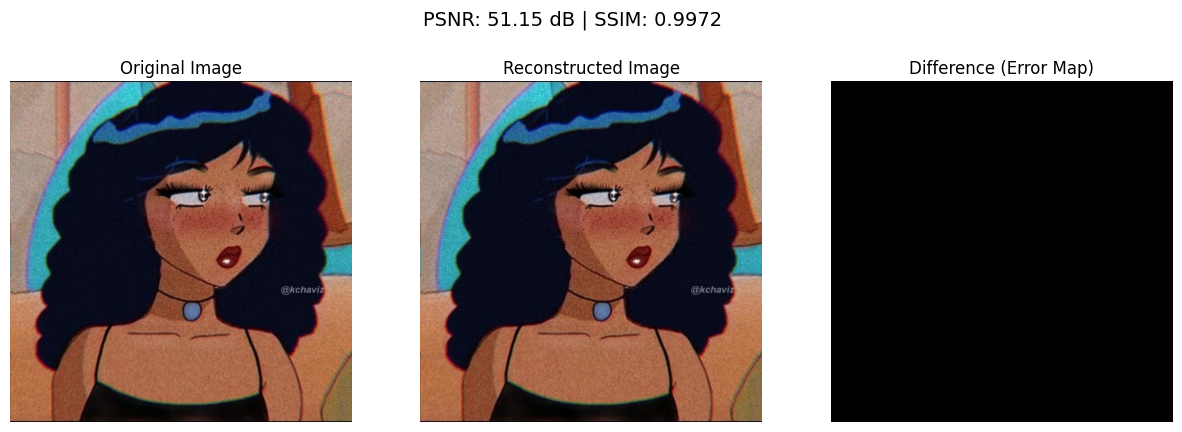

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(reconstructed_image)
axes[1].set_title("Reconstructed Image")
axes[1].axis("off")

difference = cv2.absdiff(image, reconstructed_image)
axes[2].imshow(difference)
axes[2].set_title("Difference (Error Map)")
axes[2].axis("off")

plt.suptitle(f"PSNR: {psnr_value:.2f} dB | SSIM: {ssim_value:.4f}", fontsize=14)
plt.show()

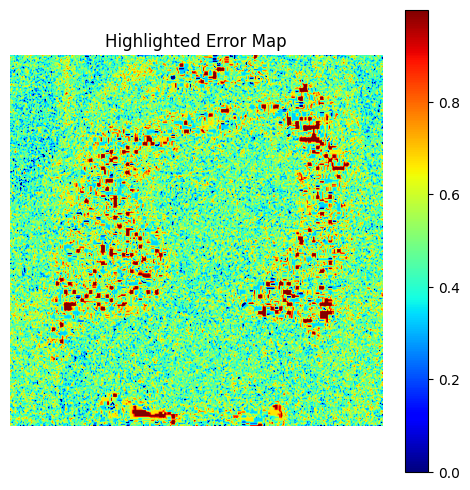

In [34]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

error_map = np.abs(image - reconstructed_image)
if len(error_map.shape) == 3:
    error_map = np.mean(error_map, axis=-1)
error_map = (error_map - np.min(error_map)) / (np.max(error_map) - np.min(error_map) + 1e-8)
error_map_blurred = cv2.GaussianBlur(error_map, (5, 5), 0
threshold = 0.2 
error_map_highlighted = np.where(error_map_blurred > threshold, error_map_blurred, 0)

plt.figure(figsize=(6,6))
plt.title("Highlighted Error Map")
plt.imshow(error_map_highlighted, cmap='jet', interpolation='nearest')
plt.colorbar()
plt.axis("off")
plt.show()


## Key Insights from the Error Map
### High Error Regions (Red): Found along the edges, indicating poor reconstruction of fine details.

### Moderate Errors (Yellow-Green): Spread across textured areas, suggesting blurring or loss of detail.

### Low Errors (Blue): Smooth regions with minimal distortion, showing good reconstruction.

# Audio Reconstruction

In [2]:
import pywt
import numpy as np
import librosa
import soundfile as sf
from Crypto.Cipher import AES, PKCS1_OAEP
from Crypto.PublicKey import RSA
from Crypto.Random import get_random_bytes
from IPython.display import Audio
import matplotlib.pyplot as plt
import librosa.display

## Load Original Audio

In [4]:
original_audio, sr = librosa.load(r"K:\Downloads\original.wav", sr=None)
print(f"Original audio loaded: {len(original_audio)} samples at {sr} Hz")

Original audio loaded: 262094 samples at 44100 Hz


## Apply DWT 

In [14]:
coeff_array = coeff_array.astype(np.float64)
coeff_bytes = coeff_array.tobytes()
data_len = len(coeff_bytes)
shape = coeff_array.shape

## AES Encrypt the Coefficients

In [15]:
aes_key = get_random_bytes(32)
cipher_aes = AES.new(aes_key, AES.MODE_EAX)
ciphertext, tag = cipher_aes.encrypt_and_digest(coeff_bytes)
nonce = cipher_aes.nonce

## RSA Encrypt the AES key 

In [16]:
rsa_key = RSA.generate(2048)
cipher_rsa = PKCS1_OAEP.new(rsa_key.publickey())
encrypted_aes_key = cipher_rsa.encrypt(aes_key)

## Decrypt AES key using RSA

In [17]:
cipher_rsa_dec = PKCS1_OAEP.new(rsa_key)
decrypted_aes_key = cipher_rsa_dec.decrypt(encrypted_aes_key)

## Decrypt Coefficients using AES

In [18]:
cipher_aes_dec = AES.new(decrypted_aes_key, AES.MODE_EAX, nonce=nonce)
decrypted_bytes = cipher_aes_dec.decrypt_and_verify(ciphertext, tag)

In [19]:
decrypted_bytes = decrypted_bytes[:data_len]  # Truncate to original byte length
reconstructed_array = np.frombuffer(decrypted_bytes, dtype=np.float64).reshape(shape)

## Reconstruct Coeffs & Audio 

In [24]:
expected_size = np.prod(coeff_array.shape)
reconstructed_array = np.frombuffer(decrypted_bytes, dtype=np.float64)

if reconstructed_array.size > expected_size:
    reconstructed_array = reconstructed_array[:expected_size]
elif reconstructed_array.size < expected_size:
    reconstructed_array = np.pad(reconstructed_array, (0, expected_size - reconstructed_array.size))

reconstructed_array = reconstructed_array.reshape(coeff_array.shape)
reconstructed_coeffs = pywt.array_to_coeffs(reconstructed_array, coeff_slices, output_format='wavedec')
reconstructed_audio = pywt.waverec(reconstructed_coeffs, 'haar')
sf.write("reconstructed.wav", reconstructed_audio, sr)
print("Reconstructed audio saved.")

Reconstructed audio saved.


## Compute spectrograms and decibals

In [21]:
original_spec = np.abs(librosa.stft(original_audio))
reconstructed_spec = np.abs(librosa.stft(reconstructed_audio))
original_db = librosa.amplitude_to_db(original_spec, ref=np.max)
reconstructed_db = librosa.amplitude_to_db(reconstructed_spec, ref=np.max)
error_map = np.abs(original_db - reconstructed_db)
error_map = (error_map - error_map.min()) / (error_map.max() - error_map.min() + 1e-8)

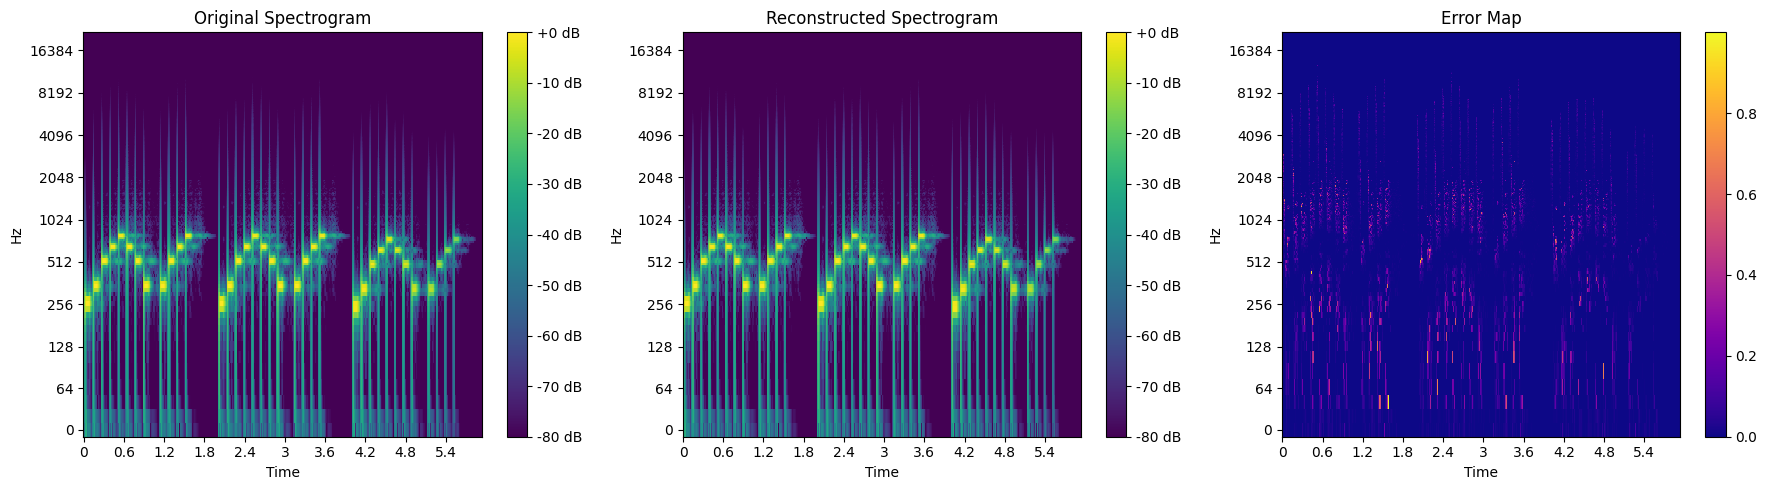

In [22]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
librosa.display.specshow(original_db, sr=sr, x_axis='time', y_axis='log', cmap='viridis')
plt.title("Original Spectrogram")
plt.colorbar(format="%+2.0f dB")

plt.subplot(1, 3, 2)
librosa.display.specshow(reconstructed_db, sr=sr, x_axis='time', y_axis='log', cmap='viridis')
plt.title("Reconstructed Spectrogram")
plt.colorbar(format="%+2.0f dB")

plt.subplot(1, 3, 3)
librosa.display.specshow(error_map, sr=sr, x_axis='time', y_axis='log', cmap='plasma')
plt.title("Error Map")
plt.colorbar()
plt.tight_layout()
plt.show()

In [23]:
print("🎧 Original Audio:")
display(Audio(original_audio, rate=sr))

print("🎧 Reconstructed Audio:")
display(Audio(reconstructed_audio, rate=sr))

🎧 Original Audio:


🎧 Reconstructed Audio:
